In [ ]:
import awswrangler as wr
import pandas as pd

# Función para auditar tablas
def auditar_tabla(database, table):
    print(f"\n--- AUDITANDO TABLA: {table} ---")
    df = wr.athena.read_sql_query(f'SELECT * FROM "{database}"."{table}" LIMIT 1000', database=database)
    
    # Mostrar columnas y nulos
    resumen = pd.DataFrame({
        'Tipo': df.dtypes,
        'Nulos': df.isnull().sum(),
        'Pct_Nulos': (df.isnull().sum() / len(df)) * 100
    })
    print(resumen)
    print("\nPrimeras filas:")
    print(df.head(3))
    return df

In [3]:
df_unad = auditar_tabla("data_lake_academico_silver", "unad_estudiantes")


--- AUDITANDO TABLA: unad_estudiantes ---
                                   Tipo  Nulos  Pct_Nulos
periodo                  string[python]      0        0.0
id                       string[python]      0        0.0
edad                     string[python]      0        0.0
sexo                     string[python]      0        0.0
estrato_social           string[python]      0        0.0
zona_de_residencia       string[python]      7        0.7
escuela                  string[python]      0        0.0
programa                 string[python]      0        0.0
zona                     string[python]      0        0.0
centro                   string[python]      0        0.0
departamento_residencia  string[python]      0        0.0
municipio_residencia     string[python]      0        0.0
source_file              string[python]      0        0.0
periodo_codigo           string[python]      0        0.0
silver_source            string[python]      0        0.0
silver_processed_at      date

In [4]:
df_creditos = auditar_tabla("data_lake_academico_silver", "spadies_creditoicetex")


--- AUDITANDO TABLA: spadies_creditoicetex ---
                               Tipo  Nulos  Pct_Nulos
tip_ictx             string[python]      0        0.0
periodo_academico    string[python]      0        0.0
valor_str            string[python]      0        0.0
silver_source        string[python]      0        0.0
silver_processed_at  datetime64[ns]      0        0.0
silver_run_id        string[python]      0        0.0

Primeras filas:
             tip_ictx periodo_academico valor_str          silver_source  \
0  No recibio credito            1998-1    95.94%  spadies_creditoicetex   
1         Largo plazo            1998-1     0.38%  spadies_creditoicetex   
2       Mediano plazo            1998-1      0.6%  spadies_creditoicetex   

      silver_processed_at     silver_run_id  
0 2026-06-24 01:52:46.618  20260624T015118Z  
1 2026-06-24 01:52:46.618  20260624T015118Z  
2 2026-06-24 01:52:46.618  20260624T015118Z  


In [5]:
df_sisben = auditar_tabla("data_lake_academico_silver", "gobierno_sisben_iv")


--- AUDITANDO TABLA: gobierno_sisben_iv ---
                                                Tipo  Nulos  Pct_Nulos
sisben_clasificacion                  string[python]      0        0.0
municipio_codigo                      string[python]      0        0.0
corte                                 string[python]      0        0.0
fex                                   string[python]      0        0.0
sisben_grupo                          string[python]      0        0.0
indicador_pobreza_ipm                 string[python]      0        0.0
hogar                                 string[python]      0        0.0
priv_bajo_logro_educativo             string[python]      0        0.0
priv_barreras_acceso_salud            string[python]      0        0.0
priv_sin_acceso_agua_mejorada         string[python]      0        0.0
priv_eliminacion_excretas_inadecuada  string[python]      0        0.0
priv_material_pisos_inadecuado        string[python]      0        0.0
priv_material_paredes_inadecuado

In [6]:
# 1. La tabla de estudiantes (histórico académico)
df_unad = auditar_tabla("data_lake_academico_silver", "unad_estudiantes")

# 2. La tabla de créditos (El apoyo financiero es un predictor)
df_creditos = auditar_tabla("data_lake_academico_silver", "spadies_creditoicetex")


--- AUDITANDO TABLA: unad_estudiantes ---
                                   Tipo  Nulos  Pct_Nulos
periodo                  string[python]      0        0.0
id                       string[python]      0        0.0
edad                     string[python]      0        0.0
sexo                     string[python]      0        0.0
estrato_social           string[python]      0        0.0
zona_de_residencia       string[python]      7        0.7
escuela                  string[python]      0        0.0
programa                 string[python]      0        0.0
zona                     string[python]      0        0.0
centro                   string[python]      0        0.0
departamento_residencia  string[python]      0        0.0
municipio_residencia     string[python]      0        0.0
source_file              string[python]      0        0.0
periodo_codigo           string[python]      0        0.0
silver_source            string[python]      0        0.0
silver_processed_at      date

Cargando datos desde Silver...


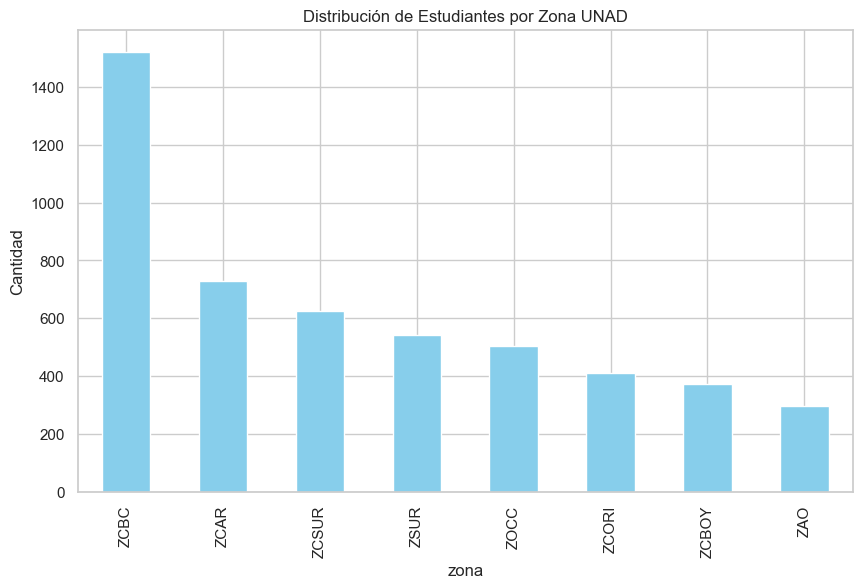

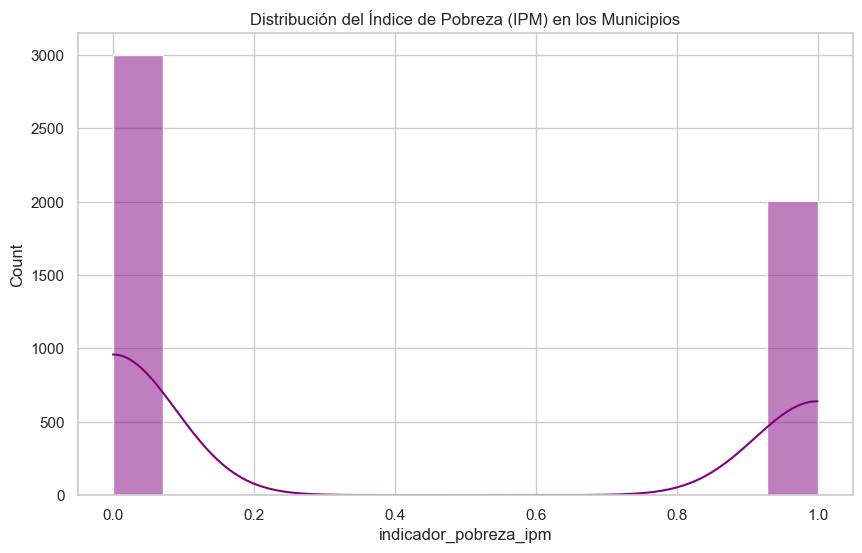

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import awswrangler as wr

# --- 1. CARGA DE DATOS (Vital para que el resto del código funcione) ---
print("Cargando datos desde Silver...")
df_unad = wr.athena.read_sql_query('SELECT * FROM "data_lake_academico_silver"."unad_estudiantes" LIMIT 5000', database="data_lake_academico_silver")
df_sisben = wr.athena.read_sql_query('SELECT * FROM "data_lake_academico_silver"."gobierno_sisben_iv" LIMIT 5000', database="data_lake_academico_silver")

# --- 2. CONFIGURACIÓN VISUAL ---
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# --- 3.  GRÁFICAS ---
plt.figure(figsize=(10, 6))
df_unad['zona'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribución de Estudiantes por Zona UNAD')
plt.ylabel('Cantidad')
plt.show()

# Análisis de pobreza (Sisbén) - Ojo: limpiamos la columna antes de graficar por si es string
sns.histplot(pd.to_numeric(df_sisben['indicador_pobreza_ipm']), kde=True, color='purple')
plt.title('Distribución del Índice de Pobreza (IPM) en los Municipios')
plt.show()